[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theochem/grid/blob/master/examples/Poisson_on_a_Molecular_Grid.ipynb)

### Poisson's Equation on a Molecular Grid

The [Interpolation and Poisson](./Interpolation_and_Poisson.ipynb) tutorial solves
$\nabla^2 \Phi = -4\pi\rho$ on a single atomic grid. This tutorial does the same on a
`MolGrid` built from several atomic grids, which is the setting relevant to computing the
Coulomb potential of a molecular charge density (see issue
[#215](https://github.com/theochem/grid/issues/215)).

The test density is a sum of two normalized $s$-type Gaussians placed on the $x$-axis,

```{math}
\rho(\mathbf{r}) = \sum_{A=1}^{2}
\left(\frac{\alpha}{\pi}\right)^{3/2} e^{-\alpha |\mathbf{r} - \mathbf{R}_A|^2},
```

which integrates to two electrons and has the known potential

```{math}
\Phi(\mathbf{r}) = \sum_{A=1}^{2}
\frac{\operatorname{erf}\!\left(\sqrt{\alpha}\, |\mathbf{r} - \mathbf{R}_A|\right)}{|\mathbf{r} - \mathbf{R}_A|},
```
so the numerical solution can be checked directly.

In [1]:
import warnings

import numpy as np
from scipy.special import erf

# scipy's solve_bvp emits harmless divide warnings while refining the far-field mesh
warnings.filterwarnings("ignore", "divide by zero encountered in divide", RuntimeWarning)
warnings.filterwarnings("ignore", "invalid value encountered in divide", RuntimeWarning)

alpha = 0.5
separation = 2.0
centers = np.array([[-separation / 2, 0.0, 0.0], [separation / 2, 0.0, 0.0]])


def density(points):
    out = np.zeros(len(points))
    for center in centers:
        r = np.linalg.norm(points - center, axis=1)
        out += (alpha / np.pi) ** 1.5 * np.exp(-alpha * r**2)
    return out


def exact_potential(points):
    out = np.zeros(len(points))
    for center in centers:
        r = np.linalg.norm(points - center, axis=1)
        with np.errstate(divide="ignore", invalid="ignore"):
            values = erf(np.sqrt(alpha) * r) / r
            values[r == 0.0] = 2.0 * np.sqrt(alpha / np.pi)  # r -> 0 limit
        out += values
    return out

#### Building the molecular grid

Each center gets its own atomic grid (a radial grid transformed onto $[0, \infty)$ times a
Lebedev angular grid). `MolGrid` glues them together with Becke's atom-in-molecule weights so
that integration over the union of grids reproduces the molecular integral.

In [2]:
from grid.onedgrid import GaussLegendre
from grid.rtransform import BeckeRTransform, InverseRTransform
from grid.atomgrid import AtomGrid
from grid.becke import BeckeWeights
from grid.molgrid import MolGrid

oned = GaussLegendre(npoints=100)
rtf = BeckeRTransform(rmin=1e-5, R=1.5)
radial = rtf.transform_1d_grid(oned)

atom_grids = [AtomGrid(radial, degrees=[20], center=center) for center in centers]
molgrid = MolGrid(
    atnums=np.array([1, 1]),
    atgrids=atom_grids,
    aim_weights=BeckeWeights(order=3),
    store=True,
)

print(f"grid points: {molgrid.size}")
print(f"integral of rho: {molgrid.integrate(density(molgrid.points)):.6f}")

grid points: 34000
integral of rho: 2.000000


#### Solving for the potential

`solve_poisson_bvp` expands the density into real spherical harmonics on each atomic grid and
solves the resulting radial boundary-value problems. `include_origin=True` adds the $r = 0$
point of each atomic grid to the radial mesh, and `remove_large_pts` drops radial points past
the given radius (in bohr) where the far-field tail is numerically noisy. The call returns a
callable that evaluates $\Phi$ at arbitrary Cartesian points.

In [3]:
from grid.poisson import solve_poisson_bvp

potential = solve_poisson_bvp(
    molgrid,
    density(molgrid.points),
    InverseRTransform(rtf),
    include_origin=True,
    remove_large_pts=10.0,
)

phi = potential(molgrid.points)
phi_exact = exact_potential(molgrid.points)

rel_l2 = np.linalg.norm(phi - phi_exact) / np.linalg.norm(phi_exact)
print(f"relative L2 error: {rel_l2:.2e}")
print(f"maximum absolute error: {np.abs(phi - phi_exact).max():.2e}")

relative L2 error: 3.68e-04
maximum absolute error: 1.60e-03


#### Potential along the bond axis

Evaluating the returned callable on a line through both centers shows the numerical and
analytic potentials on top of each other; the absolute error along the bond axis stays below
$10^{-3}$, including at the nuclei.

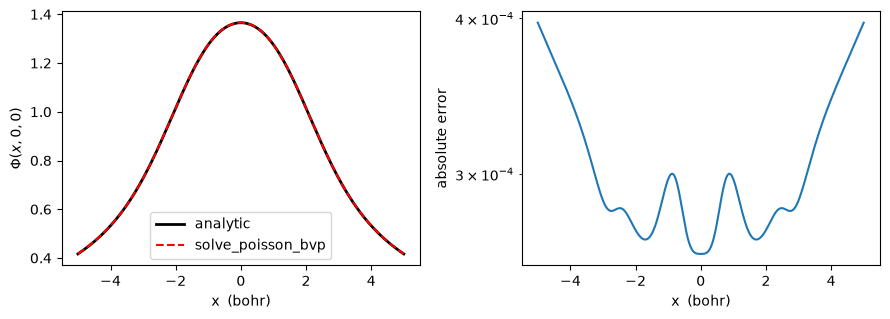

In [4]:
import matplotlib.pyplot as plt

xs = np.linspace(-5.0, 5.0, 240)
line = np.column_stack([xs, np.zeros_like(xs), np.zeros_like(xs)])

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(9, 3.3))
ax_left.plot(xs, exact_potential(line), "k-", lw=2, label="analytic")
ax_left.plot(xs, potential(line), "r--", lw=1.5, label="solve_poisson_bvp")
ax_left.set_xlabel("x  (bohr)")
ax_left.set_ylabel(r"$\Phi(x, 0, 0)$")
ax_left.legend()

ax_right.semilogy(xs, np.abs(potential(line) - exact_potential(line)) + 1e-16)
ax_right.set_xlabel("x  (bohr)")
ax_right.set_ylabel("absolute error")
fig.tight_layout()

#### Notes

- The boundary-value solver (`solve_poisson_bvp`) is the recommended method; it is more
  robust and cheaper than the initial-value solver (`solve_poisson_ivp`), especially for
  sharply peaked densities.
- `include_origin=True` is the intended setting for a grid whose radial points are all
  strictly positive. With `include_origin=False` the near-nucleus region is under-resolved
  unless the radial grid already has many points there.
- The error here is dominated by the radial grid resolution. Increasing
  `GaussLegendre(npoints=...)` is the main knob for a more accurate potential.